# Thesis Project: Leveraging Topological Data Analysis to Identify Early Warning Signals in Financial Markets

In [1]:
import yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import build_point_clouds, compute_lp_norms, detect_signals, get_signal_date, evaluate_ews
import plotly.io as pio
import plotly.graph_objects as go
from gtda.plotting import plot_point_cloud, plot_diagram
from gtda.homology import VietorisRipsPersistence
import gudhi as gd
from gtda.diagrams import PersistenceLandscape
from scipy.integrate import simpson
from itertools import product

In [2]:
# Date range
start_date = "1999-01-04"
end_date = "2021-01-01"

In [3]:
# Global style for matplotlib plots
plt.style.use("seaborn-v0_8-whitegrid")  
plt.rcParams.update({
    'figure.figsize': (10, 8),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5
})

In [4]:
# Layout for plotly
custom_template = go.layout.Template(
    layout=go.Layout(
        font=dict(size=12),
        title=dict(font=dict(size=20)),
        xaxis=dict(
            title_font=dict(size=16),
            tickfont=dict(size=10)
        ),
        yaxis=dict(
            title_font=dict(size=16),
            tickfont=dict(size=10)
        ),
        legend=dict(font=dict(size=14))
    )
)

# Apply as default
pio.templates["custom_thesis"] = custom_template
pio.templates.default = "custom_thesis+plotly_white"


# Step 1: Retrieve data 

In [5]:
SP500 = yfinance.Ticker("^GSPC")
hist = SP500.history(start=start_date, end=end_date)
sp500_df = hist['Close']

NASDAQ = yfinance.Ticker("^IXIC")
hist = NASDAQ.history(start=start_date, end=end_date)
nasdaq_df = hist['Close']

DJIA = yfinance.Ticker("^DJI")
hist = DJIA.history(start=start_date, end=end_date)
djia_df = hist['Close']

RUSSELL2000 = yfinance.Ticker("^RUT")
hist = RUSSELL2000.history(start=start_date, end=end_date)
russell2000_df = hist['Close']

In [6]:
sp500_df = sp500_df.rename("S&P 500")
nasdaq_df = nasdaq_df.rename("NASDAQ")
djia_df = djia_df.rename("DJIA")
russell2000_df = russell2000_df.rename("Russell 2000")

us_df = pd.concat([sp500_df, nasdaq_df, djia_df, russell2000_df], axis=1)
us_df.index = pd.to_datetime(us_df.index).date
us_df = us_df.groupby(us_df.index).last()

<Axes: xlabel='Date'>

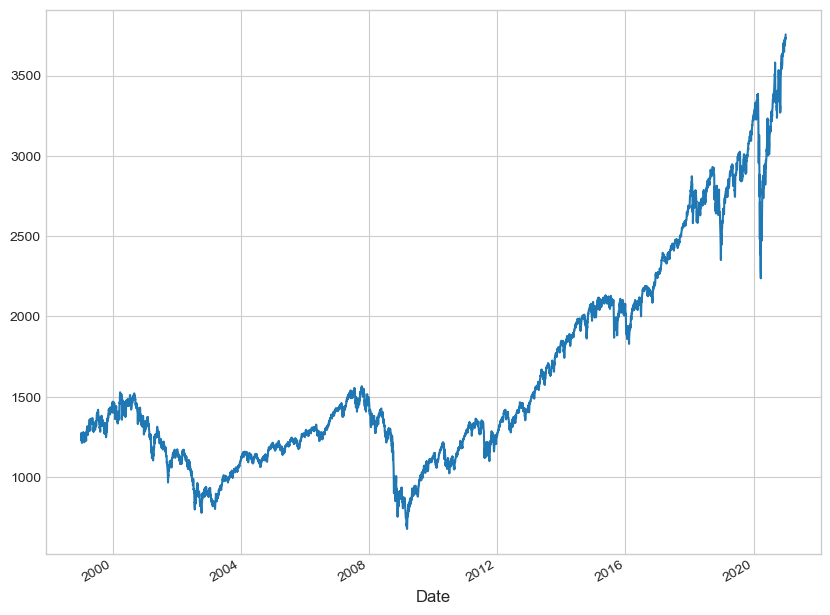

In [7]:
sp500_df.plot()

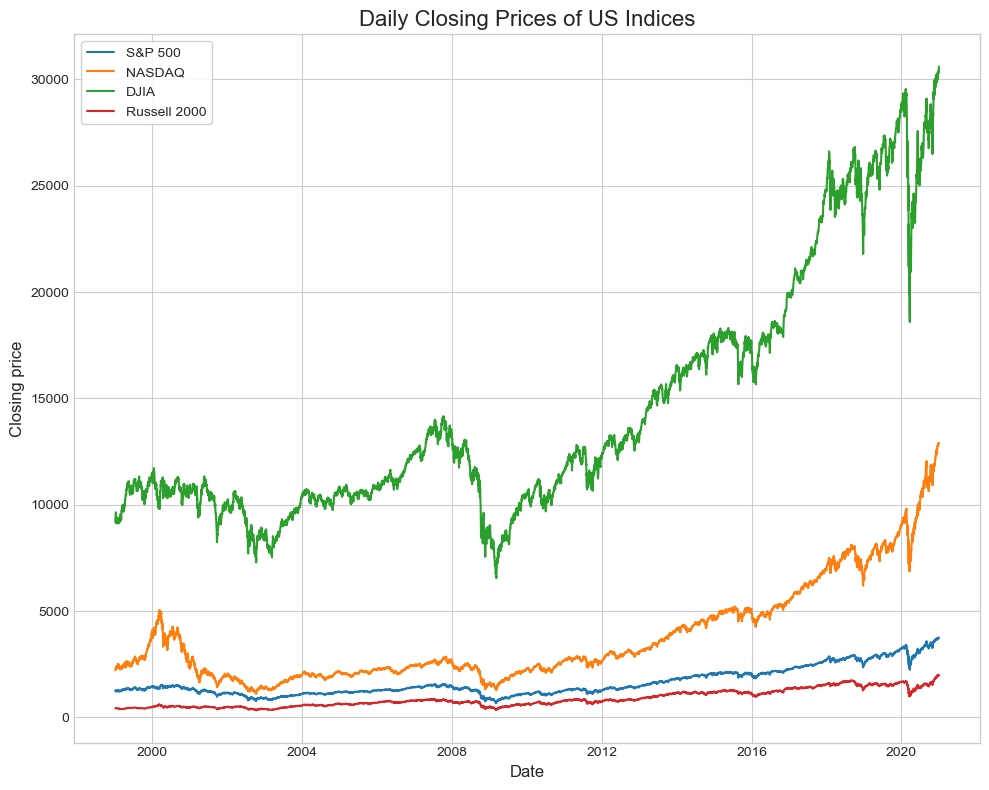

In [8]:
us_df.plot()
plt.title("Daily Closing Prices of US Indices")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_closing_price.png", dpi=300)
plt.show()

In [9]:
us_df.head()

,S&P 500,NASDAQ,DJIA,Russell 2000
1999-01-04,1228.099976,2208.050049,9184.269531,421.260010
1999-01-05,1244.780029,2251.270020,9311.190430,422.089996
1999-01-06,1272.339966,2320.860107,9544.969727,427.790009
1999-01-07,1269.729980,2326.090088,9537.759766,427.829987
1999-01-08,1275.089966,2344.409912,9643.320312,431.230011


In [10]:
us_df.tail()

,S&P 500,NASDAQ,DJIA,Russell 2000
2020-12-24,3703.060059,12804.730469,30199.869141,2003.949951
2020-12-28,3735.360107,12899.419922,30403.970703,1996.250000
2020-12-29,3727.040039,12850.219727,30335.669922,1959.359985
2020-12-30,3732.040039,12870.000000,30409.560547,1979.989990
2020-12-31,3756.070068,12888.280273,30606.480469,1974.859985


In [11]:
len(us_df)

5536

In [12]:
us_df.isna().sum()

S&P 500         0
NASDAQ          0
DJIA            0
Russell 2000    0
dtype: int64

## Compute daily log returns 

In [13]:
us_df = np.log(us_df / us_df.shift(1))

In [14]:
us_df.head()

,S&P 500,NASDAQ,DJIA,Russell 2000
1999-01-04,NaN,NaN,NaN,NaN
1999-01-05,0.013491,0.019385,0.013725,0.001968
1999-01-06,0.021899,0.030443,0.024797,0.013414
1999-01-07,-0.002053,0.002251,-0.000756,0.000093
1999-01-08,0.004212,0.007845,0.011007,0.007916


In [15]:
us_df.tail()

,S&P 500,NASDAQ,DJIA,Russell 2000
2020-12-24,0.003530,0.002629,0.002322,-0.001571
2020-12-28,0.008685,0.007368,0.006736,-0.003850
2020-12-29,-0.002230,-0.003821,-0.002249,-0.018653
2020-12-30,0.001341,0.001538,0.002433,0.010474
2020-12-31,0.006418,0.001419,0.006455,-0.002594


In [16]:
us_df = us_df.dropna()
len(us_df)

5535

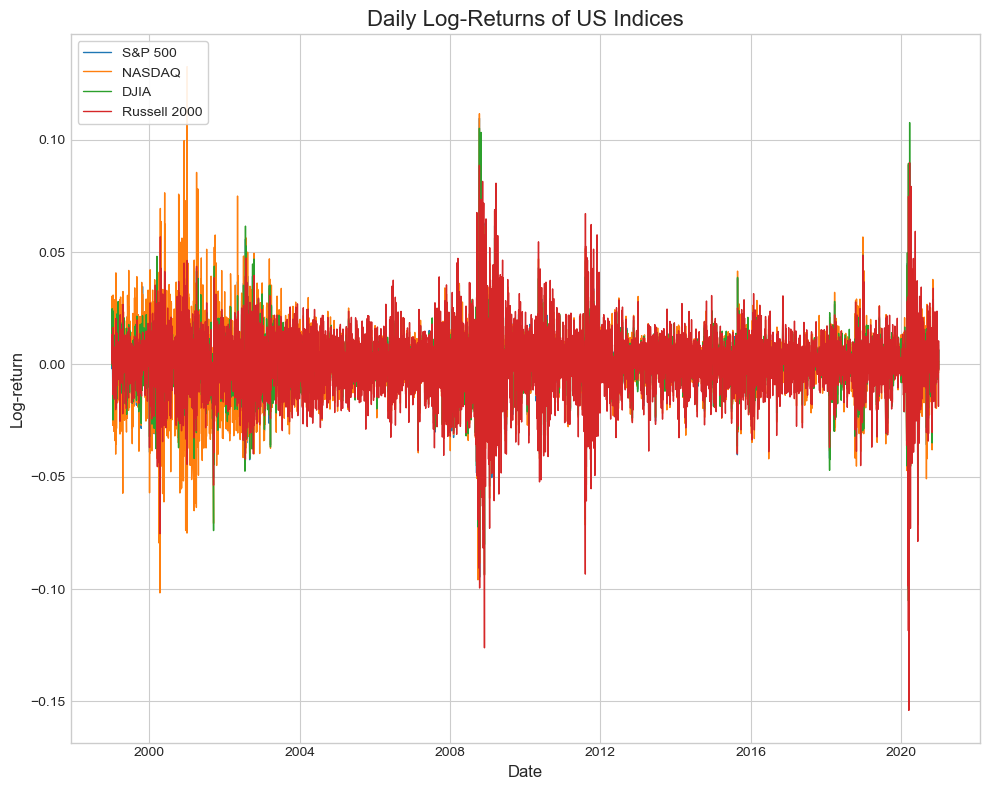

In [17]:
us_df.plot(linewidth=1)
plt.title("Daily Log-Returns of US Indices")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_log_returns.png", dpi=300)
plt.show()

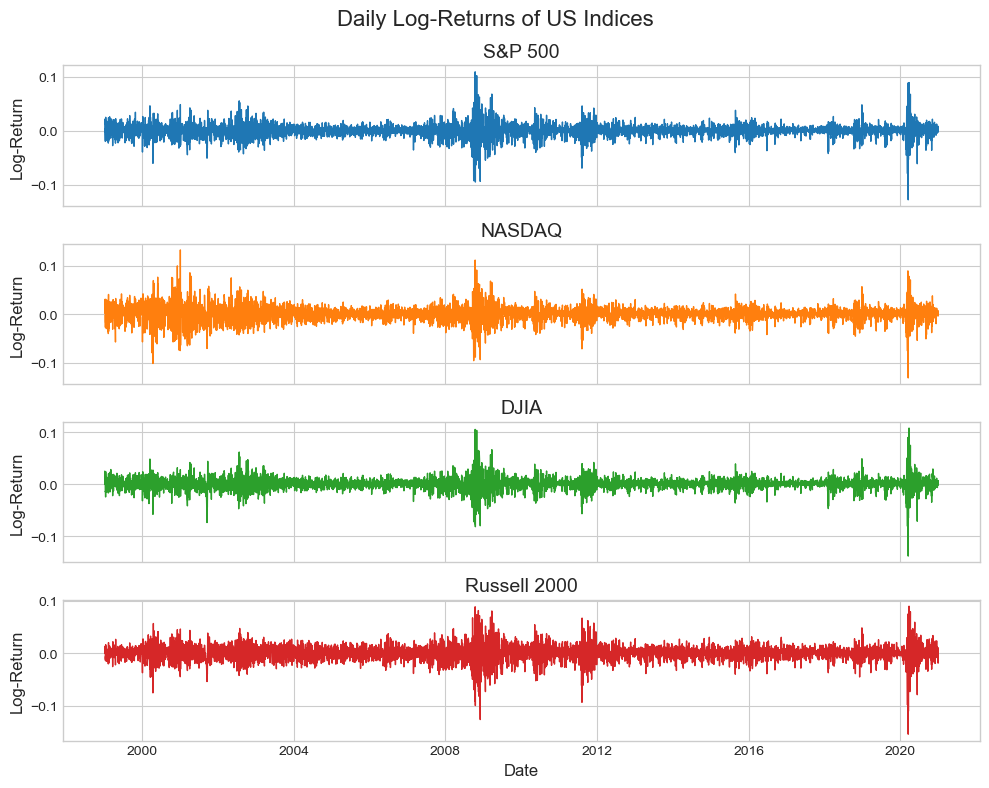

In [18]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)
indices = ["S&P 500", "NASDAQ", "DJIA", "Russell 2000"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, index in enumerate(indices):
    us_df[index].plot(ax=axes[i], color=colors[i], linewidth=1)
    axes[i].set_ylabel("Log-Return", fontsize=12)
    axes[i].set_title(f"{index}", fontsize=14)
    axes[i].grid(True)

# Set common x-label
axes[-1].set_xlabel("Date", fontsize=12)

plt.suptitle("Daily Log-Returns of US Indices", fontsize=16)
plt.tight_layout()
plt.savefig("Figures/us_log_returns_subplots.png", dpi=300)
plt.show()


# Step 2: Create point clouds

In [19]:
us_cloud_30 = build_point_clouds(us_df, 30)
us_cloud_30

[array([[ 1.34905913e-02,  1.93847149e-02,  1.37247618e-02,
          1.96830932e-03],
        [ 2.18988669e-02,  3.04433428e-02,  2.47973367e-02,
          1.34138882e-02],
        [-2.05343387e-03,  2.25093124e-03, -7.55653040e-04,
          9.34480905e-05],
        [ 4.21247349e-03,  7.84494944e-03,  1.10068476e-02,
          7.91572690e-03],
        [-8.83037918e-03,  1.69935051e-02, -2.43268652e-03,
          4.39630923e-03],
        [-1.94702103e-02, -2.71368294e-02, -1.52098492e-02,
         -1.34112101e-02],
        [-4.13110626e-03, -1.69914451e-03, -1.32937069e-02,
         -5.86704667e-03],
        [-1.81564491e-02, -1.74115022e-02, -2.47574991e-02,
         -1.12668757e-02],
        [ 2.53083772e-02,  3.08692938e-02,  2.37933778e-02,
          1.64082811e-02],
        [ 7.00530281e-03,  2.52180341e-02,  1.56933095e-03,
          8.95179730e-03],
        [ 3.68330026e-03,  3.03507051e-03, -2.06617549e-03,
         -6.26851777e-04],
        [-1.72250289e-02, -2.97361817e-02, 

### Identify a quiet period

In [20]:
# Find the location of the smallest absolute value of log return 
quiet_loc = us_df.abs().stack().idxmin()
quiet_loc

(datetime.date(2001, 6, 12), 'Russell 2000')

In [21]:
quiet_date = quiet_loc[0]   # Extract the date
quiet_position = us_df.index.get_loc(quiet_date)  # Get the row index of that date
quiet_window = max(0, quiet_position - 30 + 1)  # Get the start of the window ending at that date
quiet_window

585

### Identify a critical period

In [22]:
# Find the location of the lowest log return 
critical_loc = us_df.stack().idxmin()
critical_loc

(datetime.date(2020, 3, 16), 'Russell 2000')

In [23]:
critical_date = critical_loc[0]    # Extract the date
critical_position = us_df.index.get_loc(critical_date)
critical_window = max(0, critical_position - 30 + 1)
critical_window

5303

In [24]:
cloud = us_cloud_30[585]
fig = plot_point_cloud(cloud, 2)

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Point Cloud of US Indices - Window 585", x=0.5,
            xanchor="center")
)
fig.update_traces(marker=dict(color="#2ca02c", size=8)) 

fig.show()
fig.write_image("Figures/us_cloud_585.png", scale=3)

In [25]:
cloud = us_cloud_30[5303]
fig = plot_point_cloud(cloud, 2)

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Point Cloud of US Indices - Window 5303", x=0.5,
            xanchor="center")
)
fig.update_traces(marker=dict(color="#2ca02c", size=8)) 

fig.show()
fig.write_image("Figures/us_cloud_5303.png", scale=3)

## Step 3: Compute Persistence Diagrams and Barcodes

In [26]:
# Initialize the Vietoris–Rips persistence object from Giotto-TDA
VR = VietorisRipsPersistence(
    metric='euclidean',    # Use Euclidean distance to compute pairwise distances between points in each cloud
    homology_dimensions=[0, 1],   # Compute 0D (connected components) and 1D (loops) persistence features
    max_edge_length=0.15,        # Restrict simplicial complex to edges with length ≤ 0.15
    collapse_edges=False,         # Do not apply edge collapsing
    n_jobs=-1                   # Use all available CPU cores for parallel computation
)

# Compute persistence diagrams
us_diagram = VR.fit_transform(us_cloud_30)

In [27]:
us_diagram

array([[[0.        , 0.00427978, 0.        ],
        [0.        , 0.00466696, 0.        ],
        [0.        , 0.00468934, 0.        ],
        ...,
        [0.00217986, 0.00217986, 1.        ],
        [0.00217986, 0.00217986, 1.        ],
        [0.00217986, 0.00217986, 1.        ]],

       [[0.        , 0.00427978, 0.        ],
        [0.        , 0.00466696, 0.        ],
        [0.        , 0.00468934, 0.        ],
        ...,
        [0.00217986, 0.00217986, 1.        ],
        [0.00217986, 0.00217986, 1.        ],
        [0.00217986, 0.00217986, 1.        ]],

       [[0.        , 0.00427978, 0.        ],
        [0.        , 0.00468934, 0.        ],
        [0.        , 0.00479278, 0.        ],
        ...,
        [0.00217986, 0.00217986, 1.        ],
        [0.00217986, 0.00217986, 1.        ],
        [0.00217986, 0.00217986, 1.        ]],

       ...,

       [[0.        , 0.00323869, 0.        ],
        [0.        , 0.00329737, 0.        ],
        [0.        , 0

In [28]:
fig = plot_diagram(us_diagram[585])

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Persistence Diagram of US Indices - Window 585", x=0.5,
            xanchor="center"),
    legend=dict(
        title="Homology Class",
        font=dict(size=13), 
        bordercolor="lightgray",         
        borderwidth=0.7                
    )
)

for trace in fig.data:
    if trace.mode == 'markers':
        trace.marker.size = 10
        if "H0" in trace.name:
            trace.marker.color = "#d62728"
            trace.name = "H\u2080"  
        elif "H1" in trace.name:
            trace.marker.color = "#1f77b4"
            trace.name = "H\u2081"  

fig.show()
fig.write_image("Figures/us_diagram_585.png", scale=3)

In [29]:
fig = plot_diagram(us_diagram[5303])

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Persistence Diagram of US Indices - Window 5303", x=0.5,
            xanchor="center"),
    legend=dict(
        title="Homology Class",
        font=dict(size=13), 
        bordercolor="lightgray",       
        borderwidth=0.7                
    )
)

for trace in fig.data:
    if trace.mode == 'markers':
        trace.marker.size = 10
        if "H0" in trace.name:
            trace.marker.color = "#d62728"
            trace.name = "H\u2080"  
        elif "H1" in trace.name:
            trace.marker.color = "#1f77b4"
            trace.name = "H\u2081"  

fig.show()
fig.write_image("Figures/us_diagram_5303.png", scale=3)

/opt/anaconda3/envs/tda_env_2/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning:

usetex mode requires TeX.



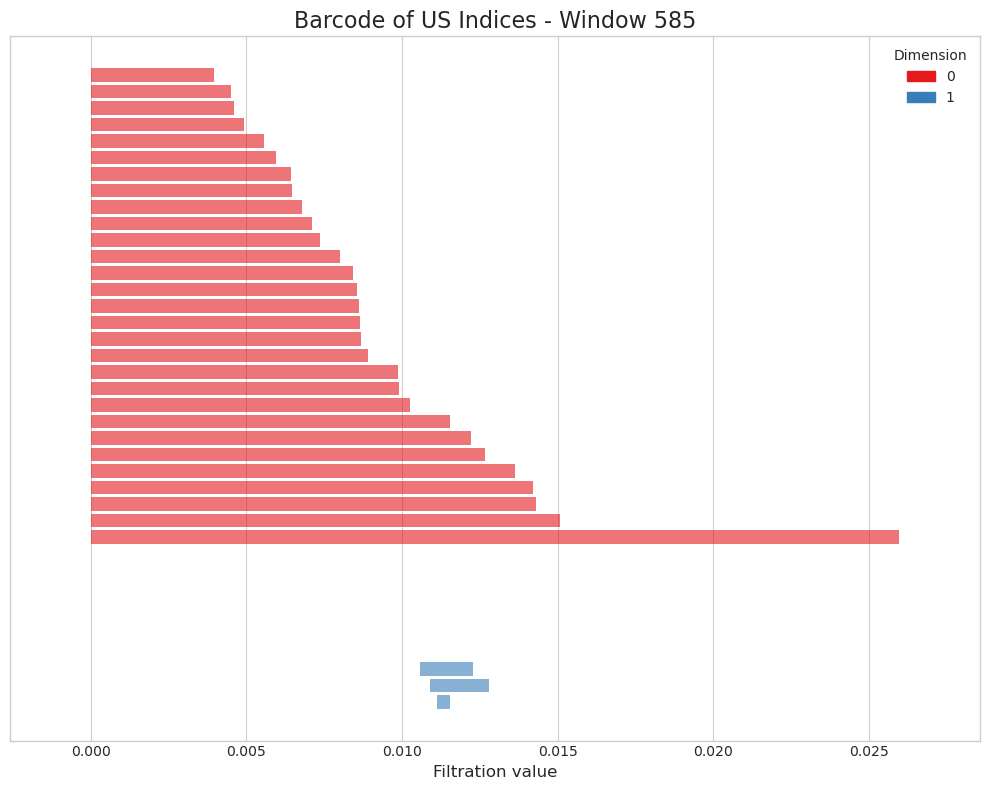

In [30]:
# Convert the diagram into the GUDHI-compatible format for plotting
# Each entry is a tuple: (dimension, (birth, death))
# - dim: homology dimension (0 or 1)
# - b, d: birth and death filtration values
diagram = us_diagram[585]
gudhi_format = [(int(dim), (float(b), float(d))) for b, d, dim in diagram]
gd.plot_persistence_barcode(gudhi_format, legend=True)
plt.title("Barcode of US Indices - Window 585")
plt.xlabel("Filtration value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_barcode_585.png", dpi=300)
plt.show()

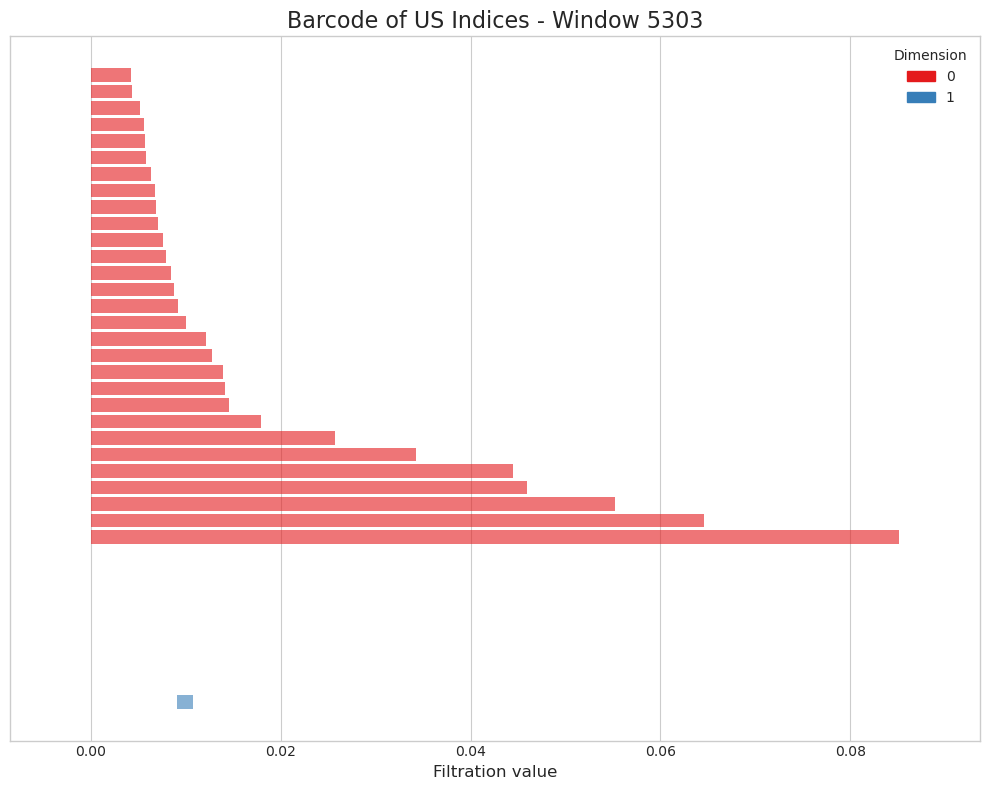

In [31]:
diagram = us_diagram[5303]
gudhi_format = [(int(dim), (float(b), float(d))) for b, d, dim in diagram]
gd.plot_persistence_barcode(gudhi_format, legend=True)
plt.title("Barcode of US Indices - Window 5303")
plt.xlabel("Filtration value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_barcode_5303.png", dpi=300)
plt.show()

## Step 4: Compute Persistent Landscapes

In [32]:
# Initialize the Persistence Landscape transformer from Giotto-TDA
# - n_layers: number of landscape layers to compute (captures the most prominent topological features)
# - n_jobs=-1: uses all available cores
PL = PersistenceLandscape(n_layers=5, n_jobs=-1)
us_landscapes = PL.fit_transform(us_diagram)

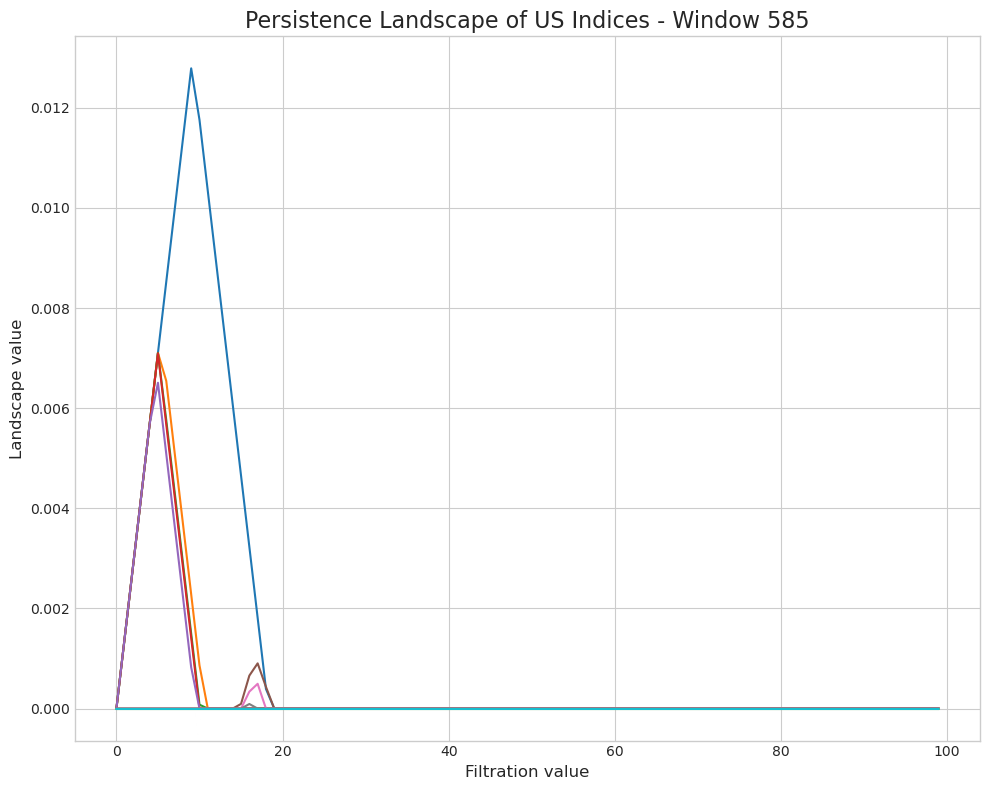

In [33]:
plt.plot(us_landscapes[585].T)
plt.title("Persistence Landscape of US Indices - Window 585")
plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_landscape_585.png", dpi=300)
plt.show()

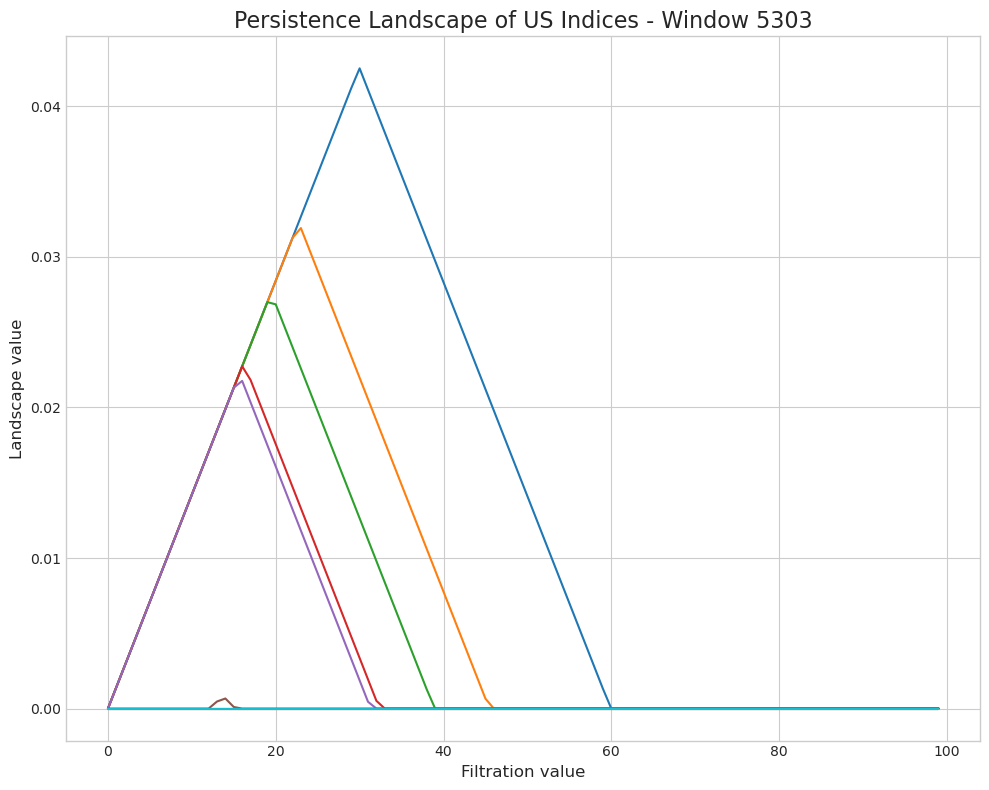

In [34]:
plt.plot(us_landscapes[5303].T)
plt.title("Persistence Landscape of US Indices - Window 5303")
plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_landscape_5303.png", dpi=300)
plt.show()


## Step 5: Compute L^p Norms

In [35]:
all_births = []
all_deaths = []

# Loop over each persistence diagram and collect birth/death times
for diagram in us_diagram:
    all_births.extend(diagram[:, 0])
    all_deaths.extend(diagram[:, 1])

# Determine the overall range of the filtration values across all diagrams
start = min(all_births)
end = max(all_deaths)

# Extract the number of bins used in each landscape layer
n_bins = us_landscapes[0].shape[1]
# Compute the grid spacing over the interval [start, end] - for Simpson's rule 
dx = (end - start) / (n_bins - 1)

l1_norms = compute_lp_norms(us_landscapes, p=1, dx=dx)
l2_norms = compute_lp_norms(us_landscapes, p=2, dx=dx)

In [36]:
# Detect warning signals in the L1 norm time series 
warning_days_l1 = detect_signals(l1_norms, alpha=1.4, beta=3, s=40, t=250)

# Convert signal indices into actual calendar dates and get the first day of each burst of consecutive warnings
dates = us_df.index[30 - 1:]       # Align the norm indices with the original DataFrame's dates
signals_l1 = get_signal_date(warning_days_l1, dates)

for d in signals_l1:
    print(d)

2000-04-14
2007-02-27
2008-09-18
2011-08-04
2015-08-24
2018-02-05
2018-12-26
2020-03-02


In [37]:
# Detect warning signals in the L2 norm time series 
warning_days_l2 = detect_signals(l2_norms, alpha=1.4, beta=3, s=40, t=250)
signals_l2 = get_signal_date(warning_days_l2, dates)

for d in signals_l2:
    print(d)

2000-04-14
2008-09-29
2011-08-04
2020-03-02


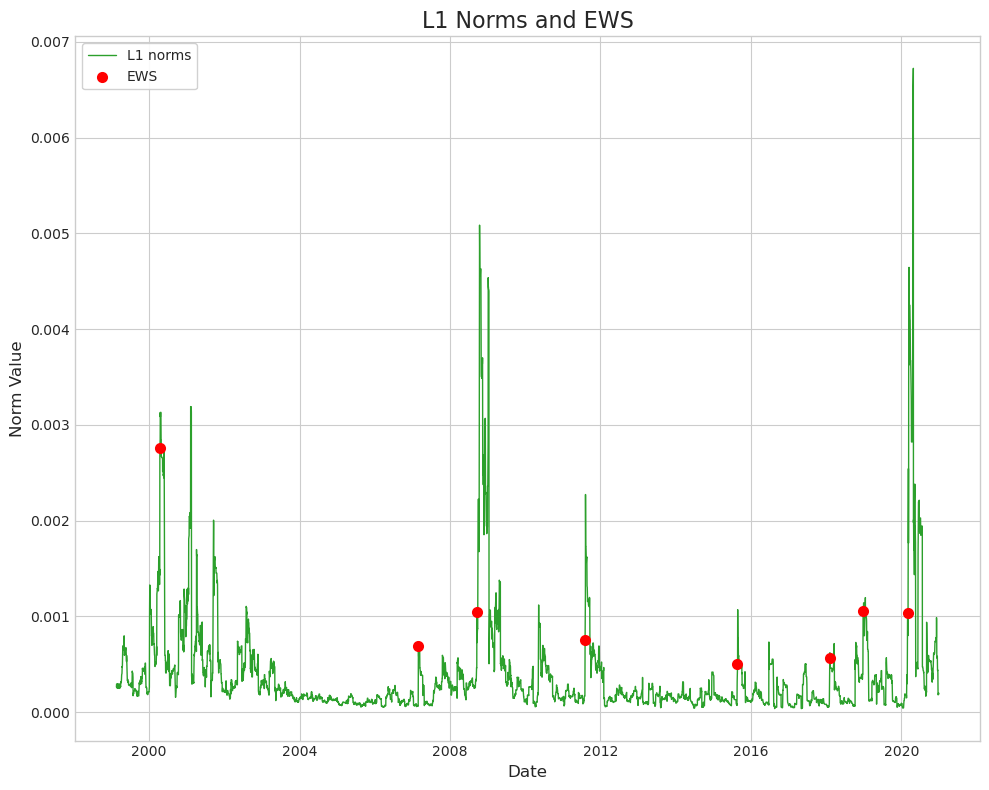

In [38]:
signal_positions = [dates.get_loc(date) for date in signals_l1]
plt.plot(dates, l1_norms, label='L1 norms', color='#2ca02c', linewidth=1, zorder=1)
plt.scatter(signals_l1, l1_norms[signal_positions], color='red', label='EWS', marker='o', linewidths=2, zorder=2)
plt.title("L1 Norms and EWS")
plt.xlabel("Date")
plt.ylabel("Norm Value")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_l1_norms.png", dpi=300)
plt.show()


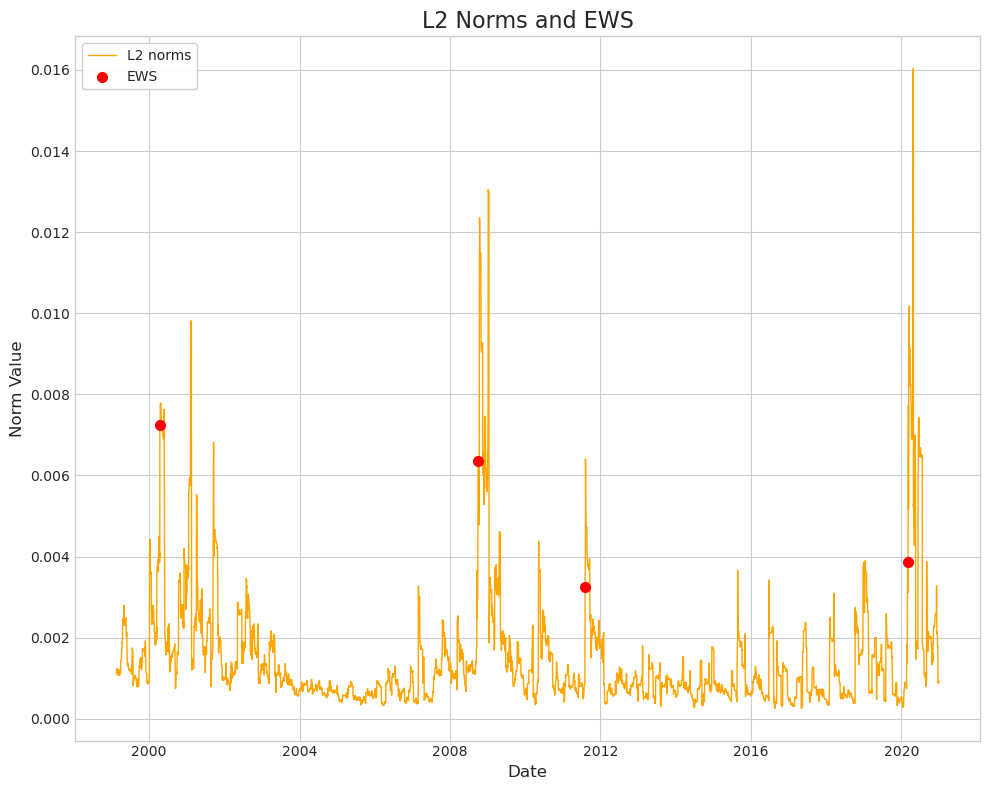

In [39]:
signal_positions = [dates.get_loc(date) for date in signals_l2]
plt.plot(dates, l2_norms, label='L2 norms', color='orange', linewidth=1, zorder=1)
plt.scatter(signals_l2, l2_norms[signal_positions], color='red', label='EWS', marker='o', linewidths=2, zorder=2)
plt.title("L2 Norms and EWS")
plt.xlabel("Date")
plt.ylabel("Norm Value")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/us_l2_norms.png", dpi=300)
plt.show()


# Validation of Results

In [40]:
# EWS from L2 norms
ews = pd.to_datetime(signals_l2)
# Ground truth of crises
crisis_dates = pd.to_datetime(["2000-03-10", "2008-09-15", "2011-08-05", "2020-02-20"])

# Evaluate the EWS against the crisis dates
result = evaluate_ews(crisis_dates,ews)
for name, value in result.items():
    print(f"{name}: {value}")

True Positives: 1
Late EWS: 3
False Negatives: 0
False Positives: 0
Precision: 0.25
Recall: 0.25
F1 score: 0.25
False alarm rate: 0.0
Mean lead time: 1.0
Mean delay time: 20.0


## Sensitivity Analysis

In [41]:
# Search grids for the hyperparameters
alpha_grid = [2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3]
beta_grid = [2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3]
s_grid = [55, 57, 60, 65, 70]
t_grid = [12, 15, 17, 20, 22, 25, 30]

results = []
# All possible combinations of parameters
param_combinations = list(product(alpha_grid, beta_grid, s_grid, t_grid))

for i, (alpha, beta, s, t) in enumerate(param_combinations):
    warning_days = detect_signals(l2_norms, alpha=alpha, beta=beta, s=s, t=t)     # Detect warning signals
    signals = get_signal_date(set(warning_days), dates)         # Get signal dates
    ews = pd.to_datetime(signals)
    metrics = evaluate_ews(crisis_dates, ews)       # Evaluate the EWS against the crisis dates
    metrics.update({'alpha': alpha, 'beta': beta, 's': s, 't': t})     # Add parameters to the metrics
    results.append(metrics)

df_params = pd.DataFrame(results)

In [42]:
df_params.describe()

,True Positives,Late EWS,False Negatives,False Positives,Precision,Recall,F1 score,False alarm rate,Mean lead time,Mean delay time,alpha,beta,s,t
count,2835.000000,2835.0,2835.000000,2835.000000,2835.000000,2835.000000,2835.000000,2835.000000,2835.000000,0.0,2835.000000,2835.000000,2835.000000,2835.000000
mean,3.571429,0.0,0.428571,1.507584,0.729280,0.892857,0.789512,0.270720,408.317898,NaN,2.900000,2.900000,61.400000,20.142857
std,0.572323,0.0,0.572323,1.041582,0.127305,0.143081,0.094431,0.127305,73.437767,NaN,0.258244,0.258244,5.463564,5.693821
min,2.000000,0.0,0.000000,0.000000,0.400000,0.500000,0.500000,0.000000,188.333000,NaN,2.500000,2.500000,55.000000,12.000000
25%,3.000000,0.0,0.000000,1.000000,0.667000,0.750000,0.750000,0.200000,395.500000,NaN,2.700000,2.700000,57.000000,15.000000
50%,4.000000,0.0,0.000000,1.000000,0.750000,1.000000,0.800000,0.250000,395.500000,NaN,2.900000,2.900000,60.000000,20.000000
75%,4.000000,0.0,1.000000,2.000000,0.800000,1.000000,0.889000,0.333000,505.333000,NaN,3.100000,3.100000,65.000000,25.000000
max,4.000000,0.0,2.000000,6.000000,1.000000,1.000000,1.000000,0.600000,505.333000,NaN,3.300000,3.300000,70.000000,30.000000


In [44]:
df_best_params = df_params[
    (df_params["True Positives"]==4) &
    (df_params["F1 score"]==1) &
    (df_params["Late EWS"]==0) &
    (df_params["False Negatives"]==0) &
    (df_params["False Positives"]==0) 
]

df_best_params

,True Positives,Late EWS,False Negatives,False Positives,Precision,Recall,F1 score,False alarm rate,Mean lead time,Mean delay time,alpha,beta,s,t
484,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,2.6,2.9,70,15
505,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,2.6,3.0,60,15
512,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,2.6,3.0,65,15
519,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,2.6,3.0,70,15
533,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,2.6,3.1,57,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2759,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,3.3,3.1,70,15
2760,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,3.3,3.1,70,17
2787,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,3.3,3.2,65,15
2788,4,0,0,0,1.0,1.0,1.0,0.0,282.75,NaN,3.3,3.2,65,17


In [45]:
# Get the EWS dates found with the best parameters
for alpha, beta, s, t in zip(
    df_best_params["alpha"], 
    df_best_params["beta"], 
    df_best_params["s"], 
    df_best_params["t"]
):
    print(f"Best parameters: alpha={alpha}, beta={beta}, s={s}, t={t}")
    warning_days_l2 = detect_signals(l2_norms, alpha=alpha, beta=beta, s=s, t=t)
    signals_l2 = get_signal_date(warning_days_l2, dates)

    for d in signals_l2:
        print(d)

Best parameters: alpha=2.6, beta=2.9, s=70, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.0, s=60, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.0, s=65, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.0, s=70, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.1, s=57, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.1, s=60, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.1, s=65, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.1, s=65, t=17
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.1, s=70, t=15
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.1, s=70, t=17
2000-01-04
2007-02-27
2011-08-04
2018-10-10
Best parameters: alpha=2.6, beta=3.2, s=65, t=15
2000-01-04
2007-02-27

In [46]:
warning_days_l2 = detect_signals(l2_norms, alpha=2.6, beta=2.9, s=70, t=15)
signals_l2 = get_signal_date(warning_days_l2, dates)

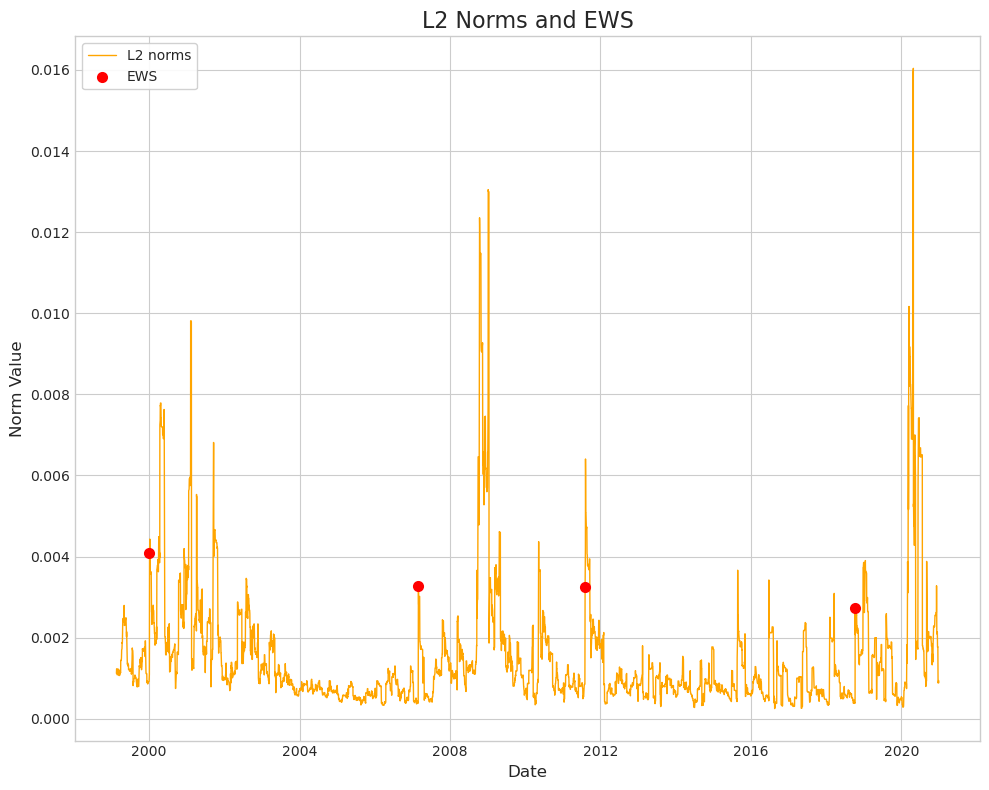

In [47]:
signal_positions = [dates.get_loc(date) for date in signals_l2]
plt.plot(dates, l2_norms, label='L2 norms', color='orange', linewidth=1, zorder=1)
plt.scatter(signals_l2, l2_norms[signal_positions], color='red', label='EWS', marker='o', linewidths=2, zorder=2)
plt.title("L2 Norms and EWS")
plt.xlabel("Date")
plt.ylabel("Norm Value")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/ews_final.png", dpi=300)
plt.show()